# Plot Zero-Variance extrapolation - 1D chain L = 20

In [67]:
import glob
import os
import sys

In [68]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
%load_ext autoreload
%autoreload 2

from src.utils import *
from src.MC_extrapol import run_monte_carlo_extrapolation
from src.plot.plotlib import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [69]:
verbose = True

In [70]:
# Settings
L = 20                                              # Length of the Markov chain
N_sim = 1000000                                     # Number of Monte Carlo simulations

## Alpha optimization

In [71]:
dossiers = glob.glob("../../datas/datas_alpha_iter_*") 

Loading and processing 4 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.44521933
Extrapolated Energy       : -0.44534568 ± 0.00044077
95% Confidence Interval   : [-0.44621931 , -0.44445170]
Absolute Error vs Exact   : 1.26e-04


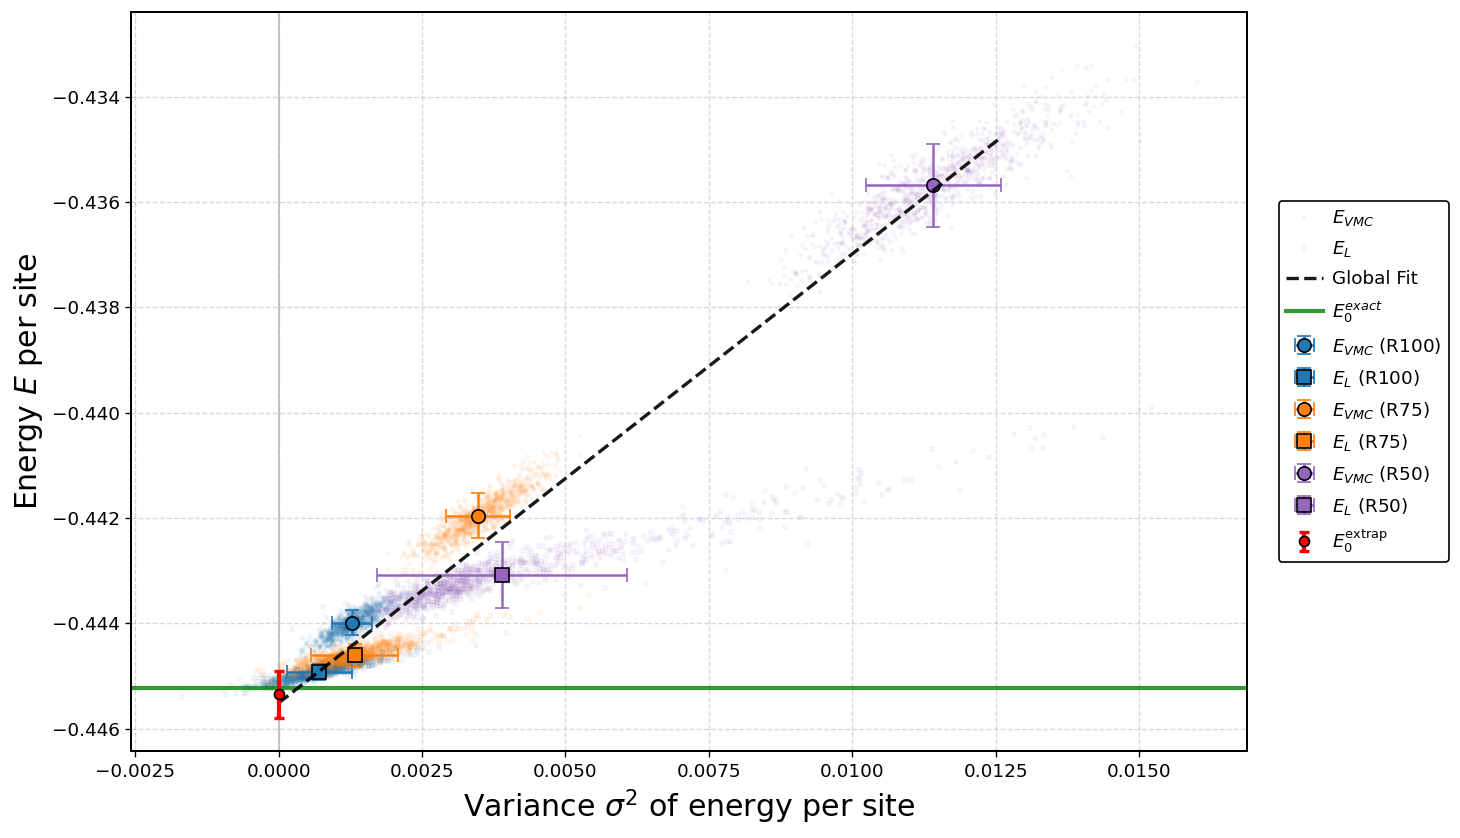

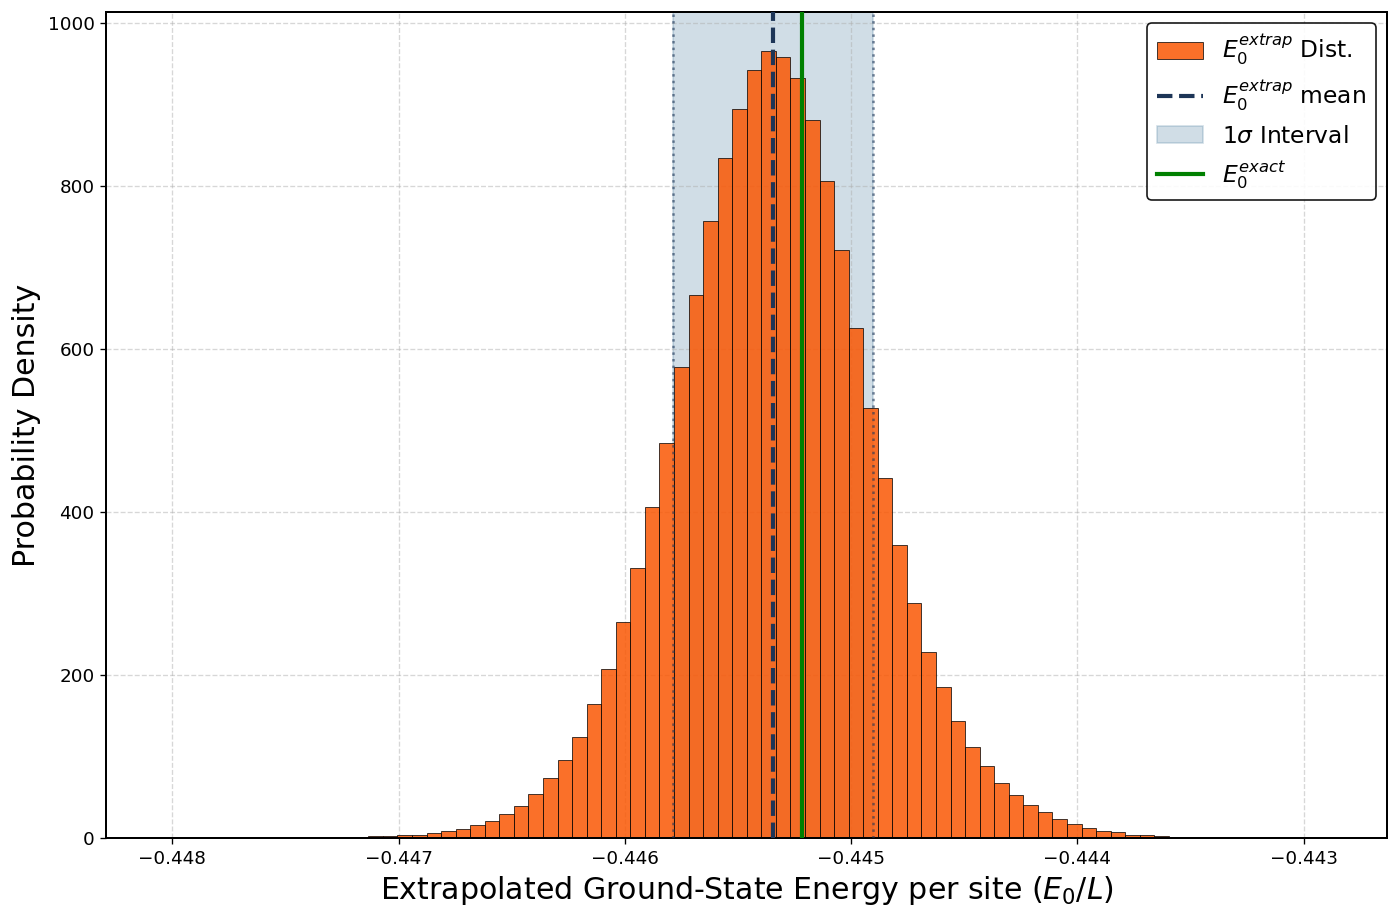

In [72]:
data_dict_AL = load_simulation_data(dossiers, L, verbose=True)
mc_results_AL = run_monte_carlo_extrapolation(data_dict_AL, N_sim, verbose=True)

plot_master_extrapolation(data_dict_AL, mc_results_AL, L, save_dir="../../assets", name="AL_extrapolation_1d_chain")
plot_extrapolation_distribution(data_dict_AL, mc_results_AL, save_dir="../../assets", name="AL_distribution_1d_chain")

In [73]:
df_results = create_results_table(data_dict_AL, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
     50   -0.435682 0.011411 0.003378       -0.443077     0.003899     0.001975
     75   -0.441954 0.003476 0.001865       -0.444607     0.001329     0.001153
    100   -0.443984 0.001277 0.001130       -0.444926     0.000707     0.000841


## Krylov Subspace 

In [74]:
dossiers = glob.glob("../../datas/datas_krylov_iter_*") 

Loading and processing 3 folders...
✅ Loading complete: 3 simulations processed!
Generating 1000000 synthetic linear regressions...

========== GLOBAL MONTE CARLO RESULTS ==========
Points used for fit       : 6 (3 simulations)
Exact Energy              : -0.44521933
Extrapolated Energy       : -0.44541380 ± 0.00037148
95% Confidence Interval   : [-0.44620393 , -0.44474720]
Absolute Error vs Exact   : 1.94e-04


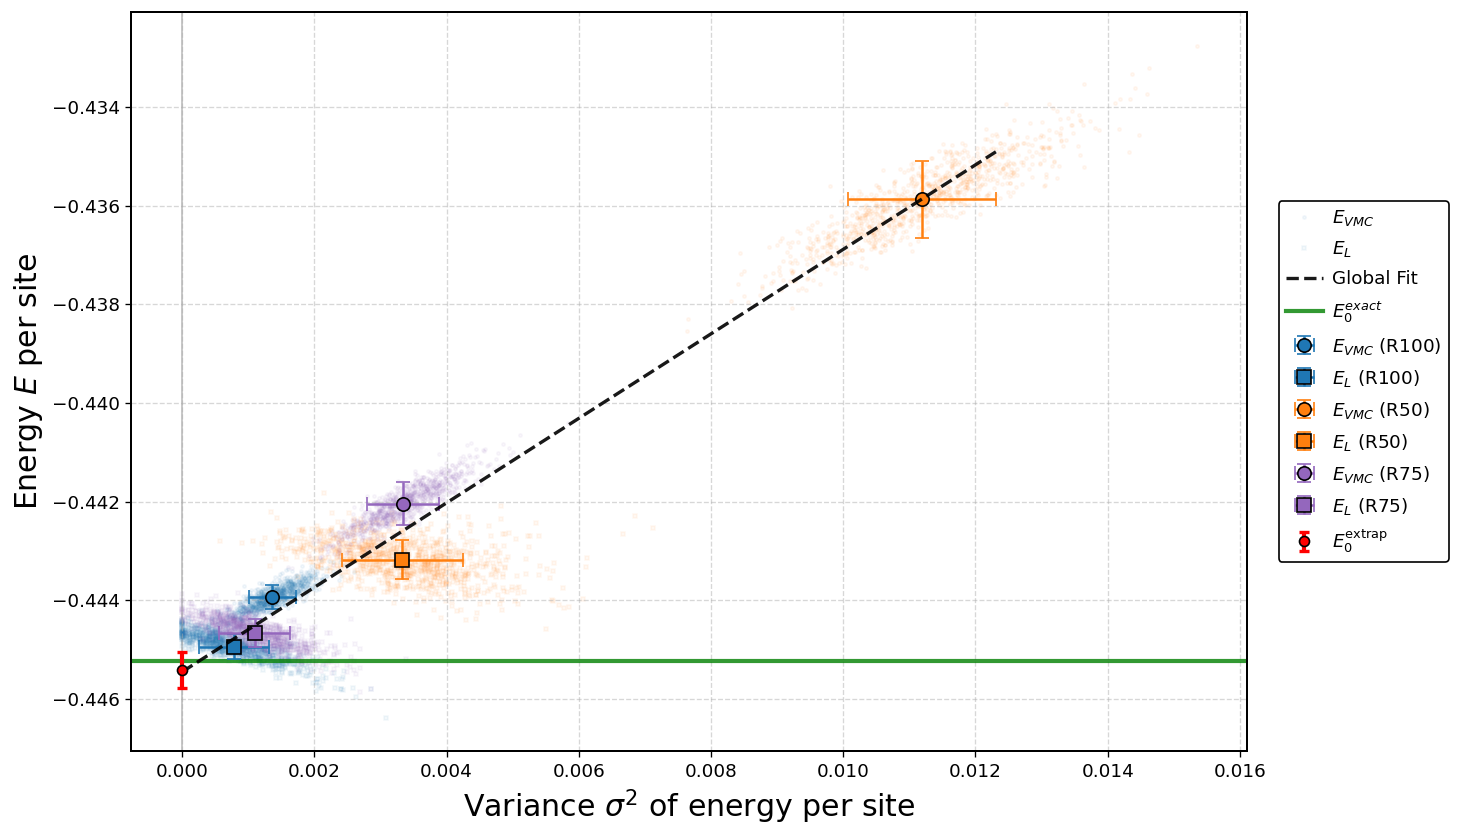

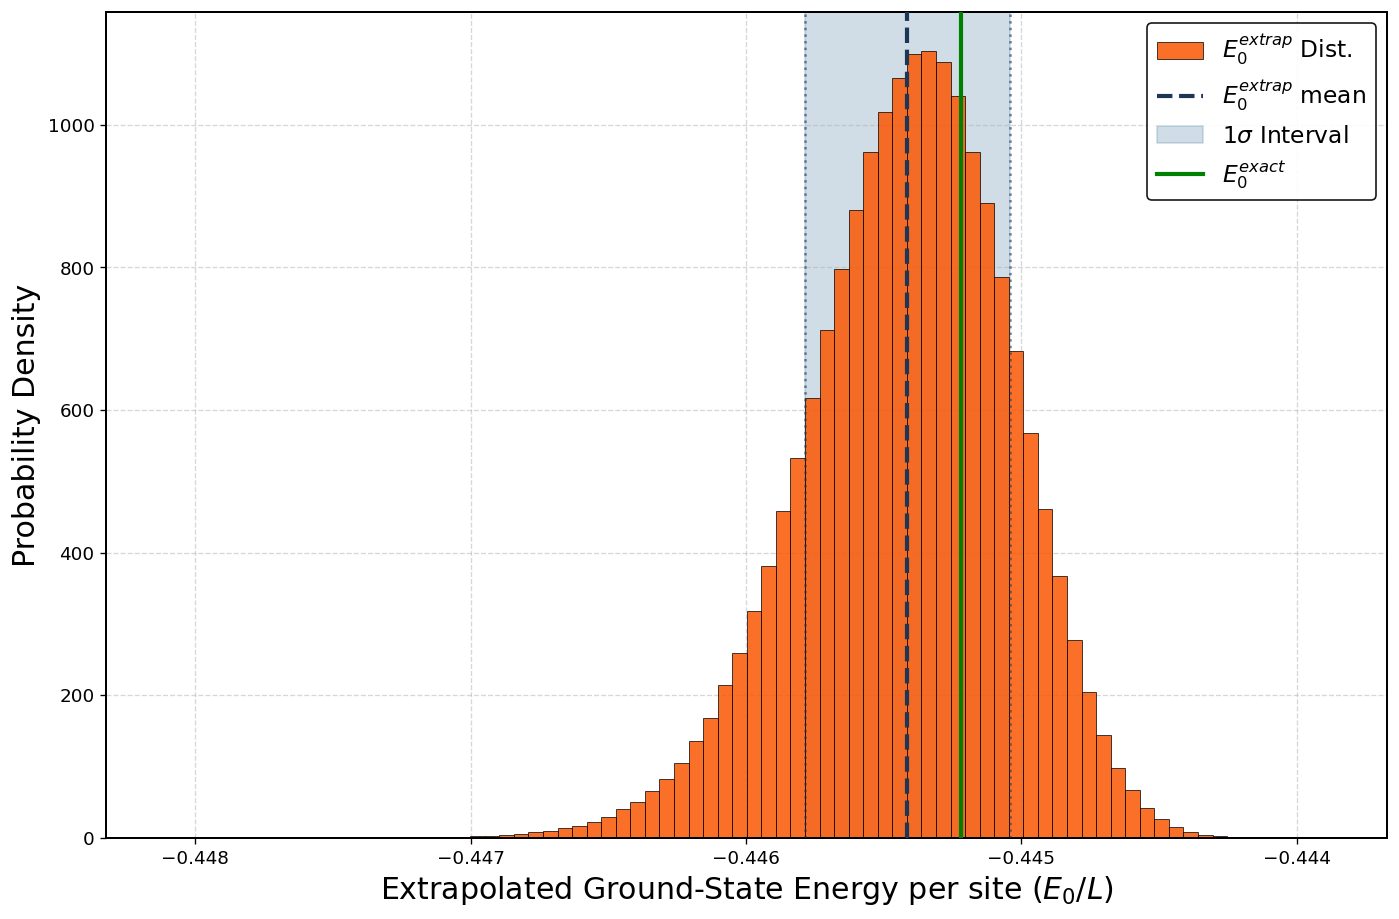

In [75]:
data_dict_KR = load_simulation_data(dossiers, L, verbose=True)
mc_results_KR = run_monte_carlo_extrapolation(data_dict_KR, N_sim, verbose=True)

plot_master_extrapolation(data_dict_KR, mc_results_KR, L, save_dir="../../assets", name="Krylov_extrapolation_1d_chain")
plot_extrapolation_distribution(data_dict_KR, mc_results_KR, save_dir="../../assets", name="Krylov_distribution_1d_chain")

In [76]:
df_results = create_results_table(data_dict_KR, L)
print(df_results.to_string(index=False))

 vmc_it  energy VMC  var VMC  sem VMC  energy lanczos  var lanczos  sem lanczos
     50   -0.435875 0.011191 0.003345       -0.443181     0.003333     0.001826
     75   -0.442038 0.003345 0.001829       -0.444658     0.001102     0.001050
    100   -0.443930 0.001366 0.001169       -0.444937     0.000784     0.000886


## Comparaison 

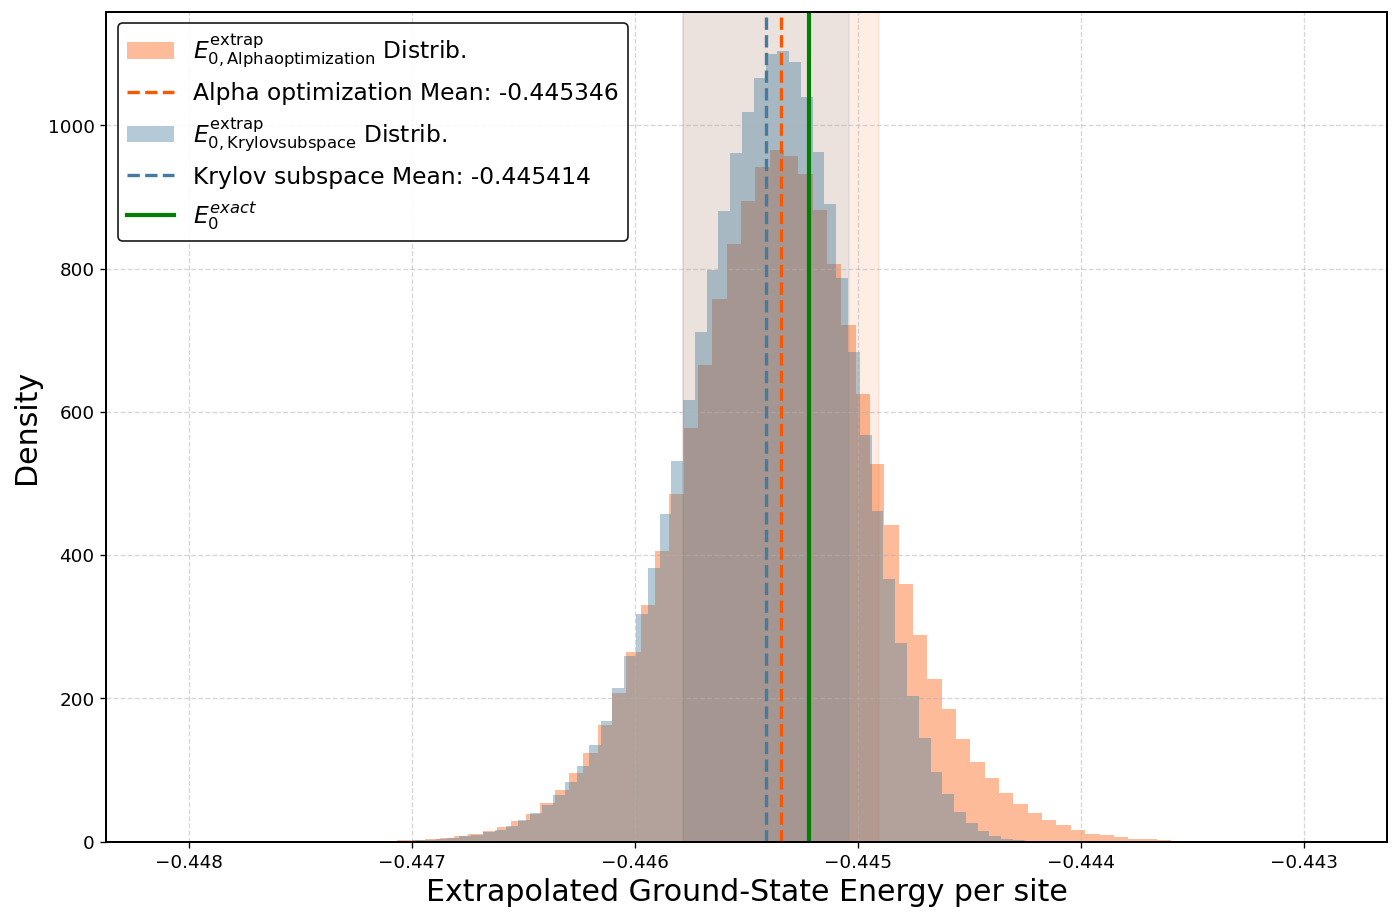

In [77]:
mes_distributions = {
    "Alpha optimization": mc_results_AL,
    "Krylov subspace": mc_results_KR
}

E_exacte = data_dict_AL["exact_gs_energy_per_site"]
plot_multiple_extrapolation_distributions(
    mes_distributions, 
    E_exacte, 
    save_dir="../../assets",
    name="extrapolation_distribution_comparison_1d_chain.png"
)